In [1]:

import os
import sys
#sys.path.append("../..")
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch

import nibabel as nib

#import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import median_filter, binary_erosion, binary_dilation, binary_fill_holes
import utils.scores as scores

#### Folders

In [2]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/home/rivage/bettik/"

In [3]:
adc_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_4_select_params/large/"
adc_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_4/large/"

flair_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_4_select_params/large/"
flair_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_4/large/"

combined_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps_select_params/3d_patch_ddpm/large/"
combined_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps/3d_patch_ddpm/large/"

combined_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_combined_registered/"


#### Make the combined ano maps

Select params

In [4]:
adc_timesteps = 110
flair_timesteps = 90


In [5]:
adc_ano_maps_select_params = os.listdir(adc_anomaly_maps_select_params_folder)
adc_ano_maps_select_params = sorted([f for f in adc_ano_maps_select_params if f"_t_{adc_timesteps}" in f])

adc_ano_maps = os.listdir(adc_anomaly_maps_folder)
adc_ano_maps = sorted([f for f in adc_ano_maps if "seg" not in f])


flair_ano_maps_select_params = os.listdir(flair_anomaly_maps_select_params_folder)
flair_ano_maps_select_params = sorted([f for f in flair_ano_maps_select_params if f"_t_{flair_timesteps}" in f])

flair_ano_maps = os.listdir(flair_anomaly_maps_folder)
flair_ano_maps = sorted([f for f in flair_ano_maps if "seg" not in f])

In [6]:
for file in tqdm(adc_ano_maps_select_params):
    adc_file = os.path.join(adc_anomaly_maps_select_params_folder, file)
    adc_img = nib.load(adc_file)

    try:
        flair_file = os.path.join(flair_anomaly_maps_select_params_folder, file.replace(f"_t_{adc_timesteps}", f"_t_{flair_timesteps}"))
        flair_img = nib.load(flair_file)
    except:
        continue
    
    combined_filepath = os.path.join(combined_anomaly_maps_select_params_folder, file.replace(f"_t_{adc_timesteps}", ""))

    adc_data = adc_img.get_fdata()
    flair_data = flair_img.get_fdata()

    combined_data = (adc_data + flair_data)/2 # average of the two anomaly maps

    combined_img = nib.Nifti1Image(combined_data, affine=adc_img.affine, header=adc_img.header)
    nib.save(combined_img, combined_filepath)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58/58 [03:46<00:00,  3.90s/it]


final metrics ano maps

In [7]:
for file in tqdm(os.listdir(adc_anomaly_maps_folder)):
    adc_file = os.path.join(adc_anomaly_maps_folder, file)
    adc_img = nib.load(adc_file)

    try:
        flair_file = os.path.join(flair_anomaly_maps_folder, file.replace(f"_t_{adc_timesteps}", f"_t_{flair_timesteps}"))
        flair_img = nib.load(flair_file)
    except:
        continue
    
    combined_filepath = os.path.join(combined_anomaly_maps_folder, file)

    adc_data = adc_img.get_fdata()
    flair_data = flair_img.get_fdata()

    combined_data = (adc_data + flair_data)/2 # average of the two anomaly maps

    combined_img = nib.Nifti1Image(combined_data, affine=adc_img.affine, header=adc_img.header)
    nib.save(combined_img, combined_filepath)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58/58 [05:40<00:00,  5.87s/it]


#### Use multicontrast_select_params.py

#### Read csv file with best params computed from multicontrast_select_params.py

In [4]:
GROUP = "large"

In [5]:
best_params_df = pd.read_csv(ROOT_DIR+f"AnoDiffExperiments/multicontrast/best_params_{GROUP}_average.csv")
best_params_dict = dict(zip(best_params_df['parameter'], best_params_df['value']))

best_median_filter_size = int(best_params_dict['median_filter_size'])
best_threshold = float(best_params_dict['threshold'])
best_erosion_dilation_iterations = int(best_params_dict['erosion_dilation_iterations'])
best_binary_fill_holes = int(best_params_dict['binary_fill_holes'])

In [6]:
metrics_result_text = f"Best Median Filter Size: {best_median_filter_size}\n"
metrics_result_text += f"Best Threshold: {best_threshold:.4f}\n"
metrics_result_text += f"Best Erosion Dilation Iterations: {best_erosion_dilation_iterations}\n"
metrics_result_text += f"Best Binary Fill Holes: {best_binary_fill_holes}\n"
print(metrics_result_text)

Best Median Filter Size: 7
Best Threshold: 0.0600
Best Erosion Dilation Iterations: 0
Best Binary Fill Holes: 0



In [12]:
adc_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_4_select_params/{GROUP}/"
adc_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_4/{GROUP}/"

flair_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_4_select_params/{GROUP}/"
flair_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_4/{GROUP}/"

combined_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps_select_params/3d_patch_ddpm/{GROUP}"
combined_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps/3d_patch_ddpm/{GROUP}/"

combined_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_combined_registered/"

combined_ano_maps_select_params = os.listdir(combined_anomaly_maps_select_params_folder)
combined_ano_maps_select_params = sorted([f for f in combined_ano_maps_select_params if "seg" not in f])

combined_ano_maps = os.listdir(combined_anomaly_maps_folder)
combined_ano_maps = sorted([f for f in combined_ano_maps if "seg" not in f])

In [7]:

combined_masks_select_params = sorted([path for path in combined_ano_maps_select_params])

combined_masks = sorted([path.replace("ano_map_", "") for path in combined_ano_maps])



In [8]:
iou_scores = []
dice_scores = []
hausdorff_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [9]:
for file in tqdm(os.listdir(combined_anomaly_maps_folder)):
    if "seg" in file:
        continue

    combined_map_path = os.path.join(combined_anomaly_maps_folder, file)
    combined_map_img = nib.load(combined_map_path)
    combined_map_data = combined_map_img.get_fdata()

    mask_path = os.path.join(combined_masks_folder, file.replace("ano_map_", ""))
    mask_img = nib.load(mask_path.replace("_t_110", ""))
    mask_data = mask_img.get_fdata()

    # Apply post-processing with the best parameters
    if best_median_filter_size > 1:
        combined_map_data = median_filter(combined_map_data, size=best_median_filter_size)

    binary_mask = combined_map_data > best_threshold

    if best_erosion_dilation_iterations > 0:
        binary_mask = binary_erosion(binary_mask, iterations=best_erosion_dilation_iterations)
        binary_mask = binary_dilation(binary_mask, iterations=best_erosion_dilation_iterations)

    if best_binary_fill_holes:
        binary_mask = binary_fill_holes(binary_mask)

    # if ano_segmentation is not torch tensor, convert it to torch tensor
    if not isinstance(binary_mask, torch.Tensor):
        ano_segmentation = torch.from_numpy(binary_mask.astype(np.float32))
    # make sure it is in bchw format (1, 1, D, H, W)
    if ano_segmentation.ndim == 3:
        ano_segmentation = ano_segmentation.unsqueeze(0).unsqueeze(0)
        
    # same for test_masks
    if not isinstance(mask_data, torch.Tensor):
        test_masks = torch.from_numpy(mask_data.astype(np.float32))
    if test_masks.ndim == 3:
        test_masks = test_masks.unsqueeze(0).unsqueeze(0)


    # Compute metrics
    iou_score, dice_score, hausdorff_distance, precision_score, recall_score, f1_score = scores.compute_scores(ano_segmentation, test_masks)


    iou_scores.append(iou_score)
    dice_scores.append(dice_score)
    hausdorff_scores.append(hausdorff_distance)
    precision_scores.append(precision_score)
    recall_scores.append(recall_score)
    f1_scores.append(f1_score)





100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58/58 [10:30<00:00, 10.87s/it]


In [10]:
# Flatten nested lists before converting to numpy array
flat_iou = [item for sublist in iou_scores for item in sublist]
flat_dice = [item for sublist in dice_scores for item in sublist]
flat_hausdorff = [item for sublist in hausdorff_scores for item in sublist]
flat_precision = [item for sublist in precision_scores for item in sublist]
flat_recall = [item for sublist in recall_scores for item in sublist]
flat_f1 = [item for sublist in f1_scores for item in sublist]


mean_iou, lower_iou, upper_iou = scores.make_confidence_intervals(np.array(flat_iou))

mean_dice, lower_dice, upper_dice = scores.make_confidence_intervals(np.array(flat_dice))

mean_hausdorff, lower_hausdorff, upper_hausdorff = scores.make_confidence_intervals(np.array(flat_hausdorff))

mean_precision, lower_precision, upper_precision = scores.make_confidence_intervals(np.array(flat_precision))

mean_recall, lower_recall, upper_recall = scores.make_confidence_intervals(np.array(flat_recall))

mean_f1, lower_f1, upper_f1 = scores.make_confidence_intervals(np.array(flat_f1))


In [11]:
print(f"Mean IoU: {mean_iou:.2f} [{lower_iou:.2f}, {upper_iou:.2f}]")
print(f"Mean Dice: {mean_dice:.2f} [{lower_dice:.2f}, {upper_dice:.2f}]")
print(f"Mean Hausdorff Distsance: {mean_hausdorff:.2f} [{lower_hausdorff:.2f}, {upper_hausdorff:.2f}]")
print(f"Mean Precision: {mean_precision:.2f} [{lower_precision:.2f}, {upper_precision:.2f}]")
print(f"Mean Recall: {mean_recall:.2f} [{lower_recall:.2f}, {upper_recall:.2f}]")
print(f"Mean F1 Score: {mean_f1:.2f} [{lower_f1:.2f}, {upper_f1:.2f}]")

Mean IoU: 0.53 [0.47, 0.59]
Mean Dice: 0.67 [0.60, 0.73]
Mean Hausdorff Distsance: 39.72 [34.03, 48.48]
Mean Precision: 0.78 [0.71, 0.85]
Mean Recall: 0.73 [0.68, 0.78]
Mean F1 Score: 0.70 [0.63, 0.76]


In [7]:
combined_ano_maps = os.listdir(combined_anomaly_maps_folder)

In [8]:
original_adc_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/adc_registered/"
original_flair_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/flair_registered/"

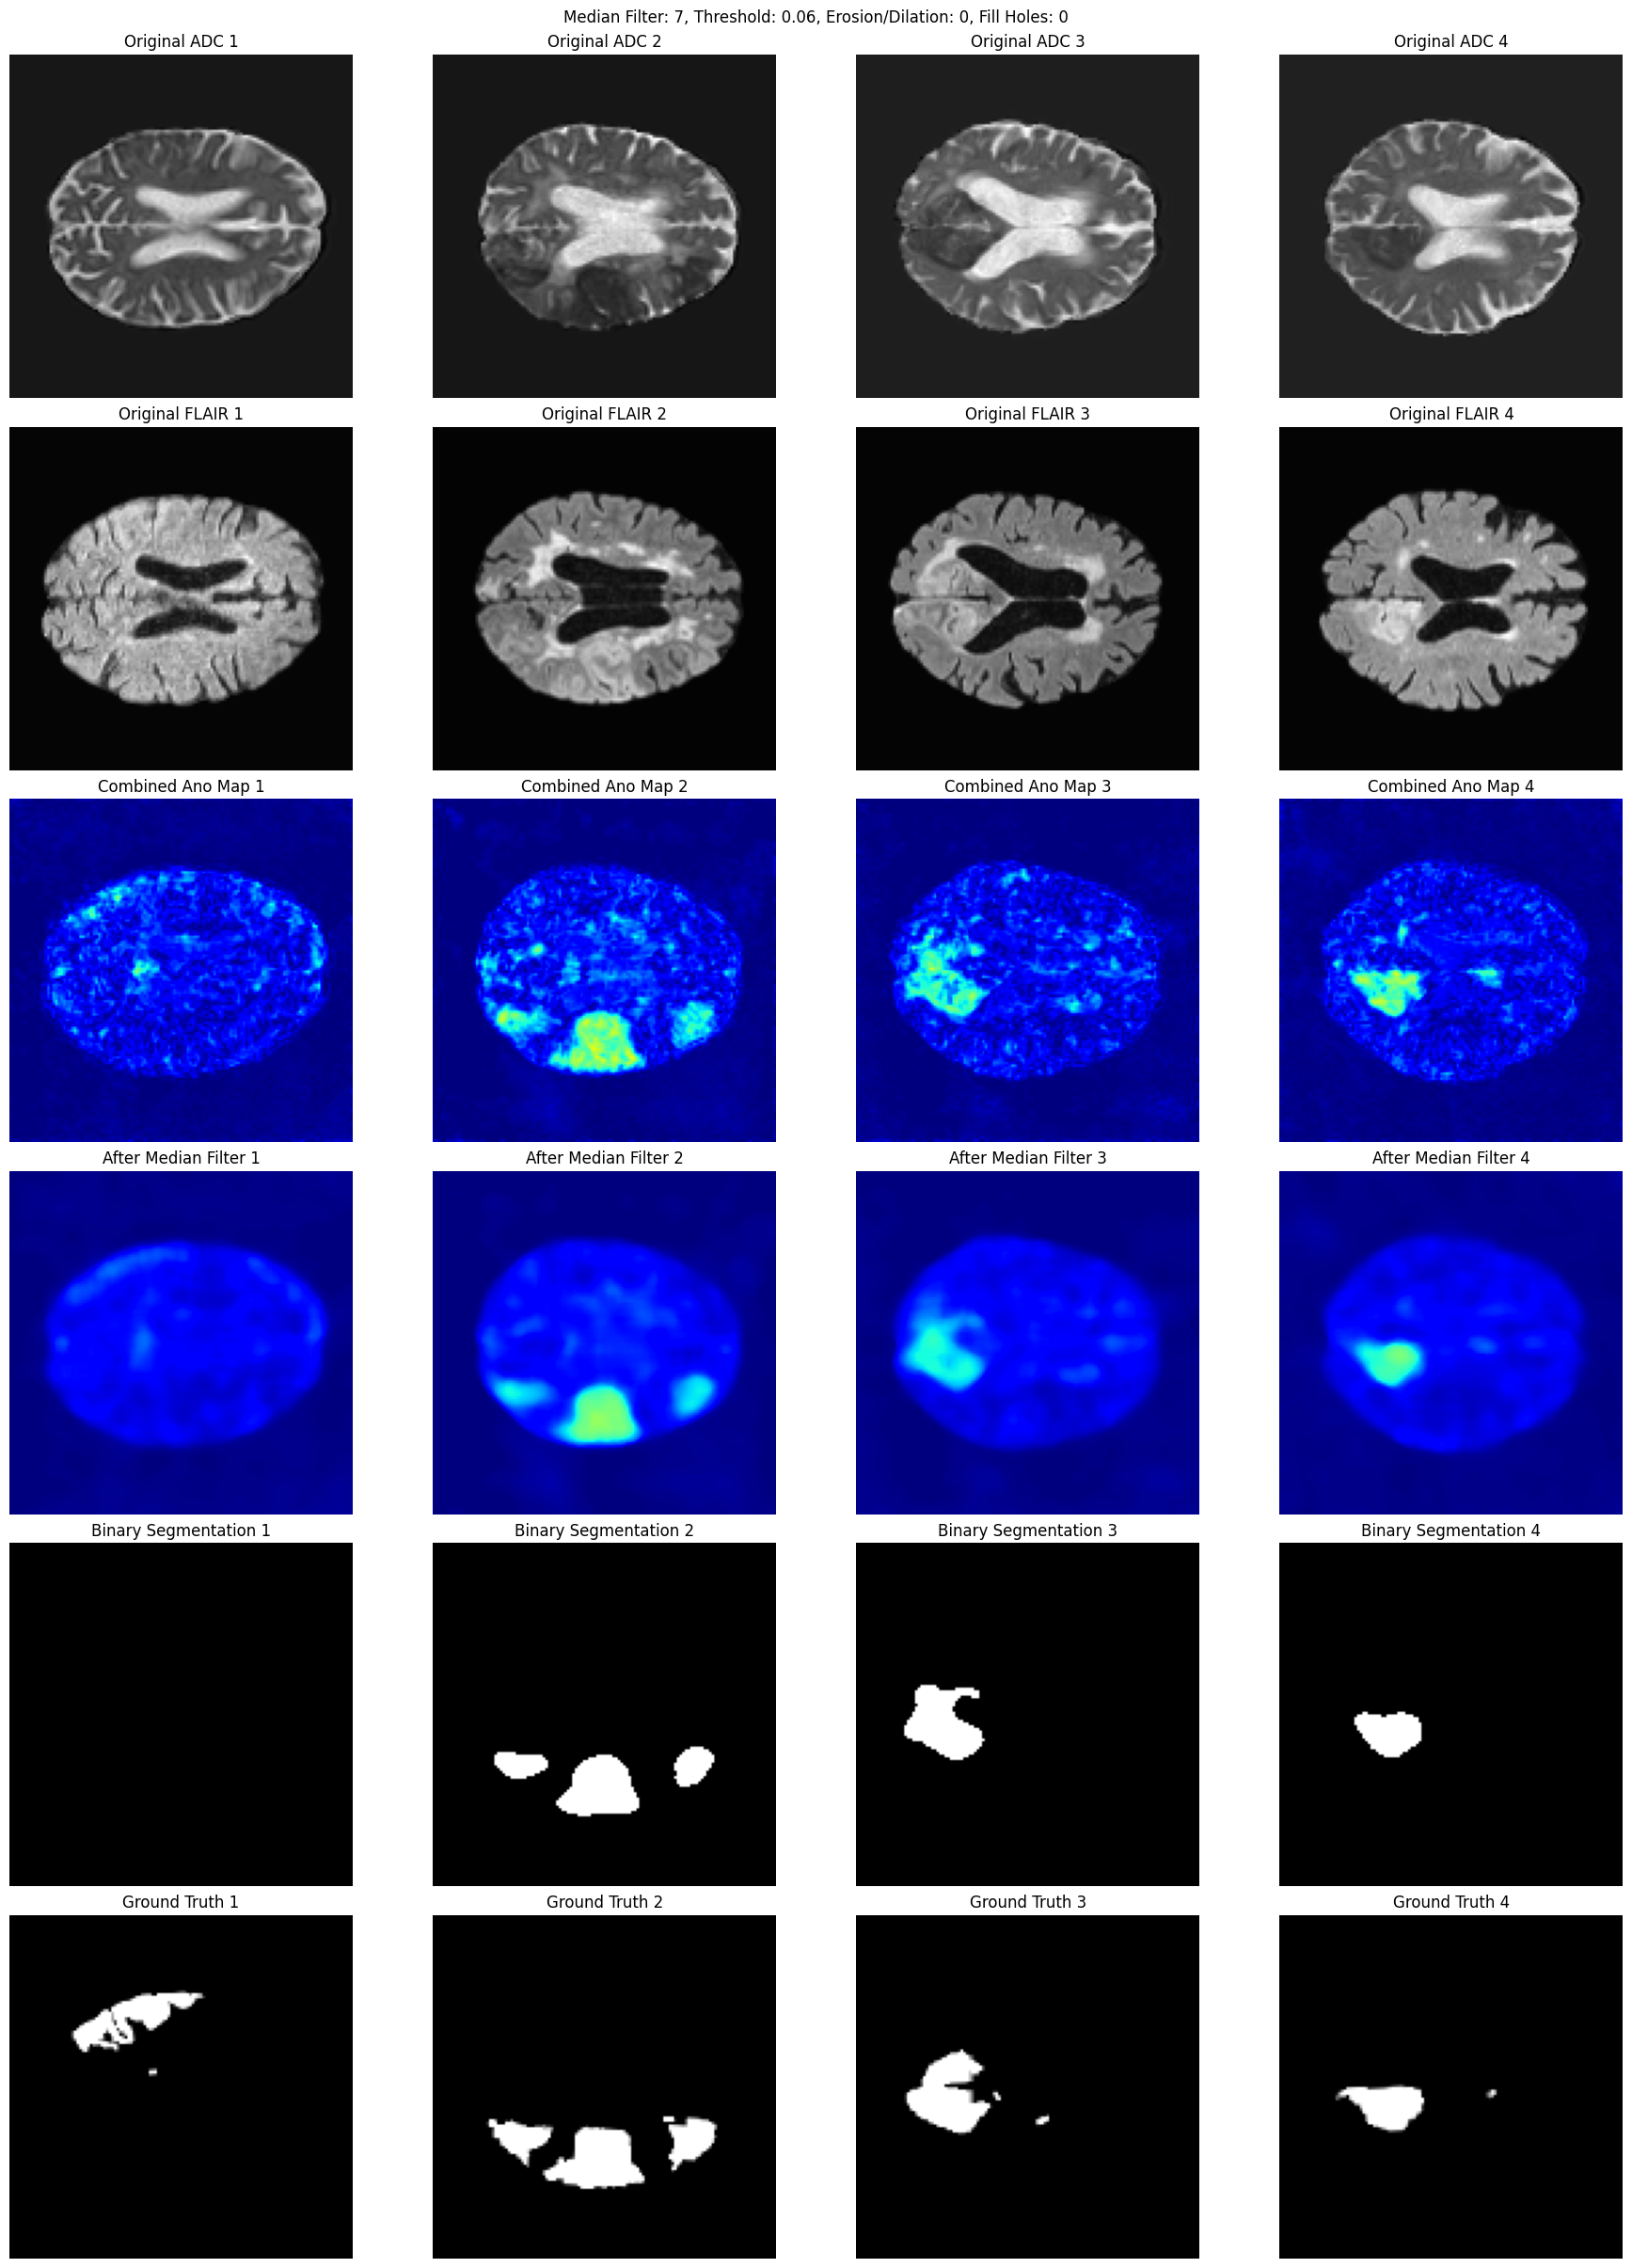

In [9]:
# ----------- PLOT -----------

fig, axes = plt.subplots(6, 4, figsize=(18, 24), constrained_layout=True)

# Load first 4 samples from combined anomaly maps
sample_files = combined_ano_maps[:4]

for idx, file in enumerate(sample_files):
    # Load combined anomaly map
    combined_map_path = os.path.join(combined_anomaly_maps_folder, file)
    combined_map_img = nib.load(combined_map_path)
    combined_map_data = combined_map_img.get_fdata()
    
    # Load ground truth mask
    mask_path = os.path.join(combined_masks_folder, file.replace("ano_map_", ""))
    mask_img = nib.load(mask_path.replace("_t_110", ""))
    mask_data = mask_img.get_fdata()
    
    # Load original ADC and FLAIR images
    adc_path = os.path.join(original_adc_folder, file.replace("_t_110", ""))
    adc_img = nib.load(adc_path)
    adc_data = adc_img.get_fdata()
    
    flair_path = os.path.join(original_flair_folder, file.replace("_t_110", ""))
    flair_img = nib.load(flair_path)
    flair_data = flair_img.get_fdata()
    
    # Get middle slice for visualization
    slice_idx = combined_map_data.shape[-1] // 2
    original_slice = combined_map_data[:, :, slice_idx]
    adc_slice = adc_data[:, :, slice_idx]
    flair_slice = flair_data[:, :, slice_idx]
    
    # Original ADC
    axes[0, idx].imshow(adc_slice, cmap='gray')
    axes[0, idx].set_title(f'Original ADC {idx+1}')
    axes[0, idx].axis('off')
    
    # Original FLAIR
    axes[1, idx].imshow(flair_slice, cmap='gray')
    axes[1, idx].set_title(f'Original FLAIR {idx+1}')
    axes[1, idx].axis('off')
    
    # Original combined anomaly map
    axes[2, idx].imshow(original_slice, cmap='jet', vmin=0, vmax=0.25)
    axes[2, idx].set_title(f'Combined Ano Map {idx+1}')
    axes[2, idx].axis('off')
    
    # Apply median filter
    if best_median_filter_size > 1:
        filtered_map = median_filter(combined_map_data, size=best_median_filter_size)
    else:
        filtered_map = combined_map_data
    
    filtered_slice = filtered_map[:, :, slice_idx]
    axes[3, idx].imshow(filtered_slice, cmap='jet', vmin=0, vmax=0.25)
    axes[3, idx].set_title(f'After Median Filter {idx+1}')
    axes[3, idx].axis('off')
    
    # Apply threshold
    binary_mask = filtered_map > best_threshold
    
    # Apply erosion/dilation
    if best_erosion_dilation_iterations > 0:
        binary_mask = binary_erosion(binary_mask, iterations=best_erosion_dilation_iterations)
        binary_mask = binary_dilation(binary_mask, iterations=best_erosion_dilation_iterations)
    
    # Apply binary fill holes
    if best_binary_fill_holes:
        binary_mask = binary_fill_holes(binary_mask)
    
    binary_slice = binary_mask[:, :, slice_idx]
    axes[4, idx].imshow(binary_slice, cmap='gray', vmin=0, vmax=1)
    axes[4, idx].set_title(f'Binary Segmentation {idx+1}')
    axes[4, idx].axis('off')
    
    # Ground truth mask
    gt_slice = mask_data[:, :, slice_idx]
    axes[5, idx].imshow(gt_slice, cmap='gray', vmin=0, vmax=1)
    axes[5, idx].set_title(f'Ground Truth {idx+1}')
    axes[5, idx].axis('off')

# Add text with parameters
param_text = f'Median Filter: {best_median_filter_size}, Threshold: {best_threshold:.2f}, '
param_text += f'Erosion/Dilation: {best_erosion_dilation_iterations}, Fill Holes: {best_binary_fill_holes}'
fig.suptitle(param_text, fontsize=12)

plt.show()


### ADC Alone

In [10]:
adc_median_filter_size = 7
adc_threshold = 0.04
adc_erosion_dilation_iterations = 6
adc_binary_fill_holes = True

Sample 19: sub-303_t_110.nii.gz
  Axial shape: (128, 128), Sagittal shape: (128, 128), Coronal shape: (128, 128)


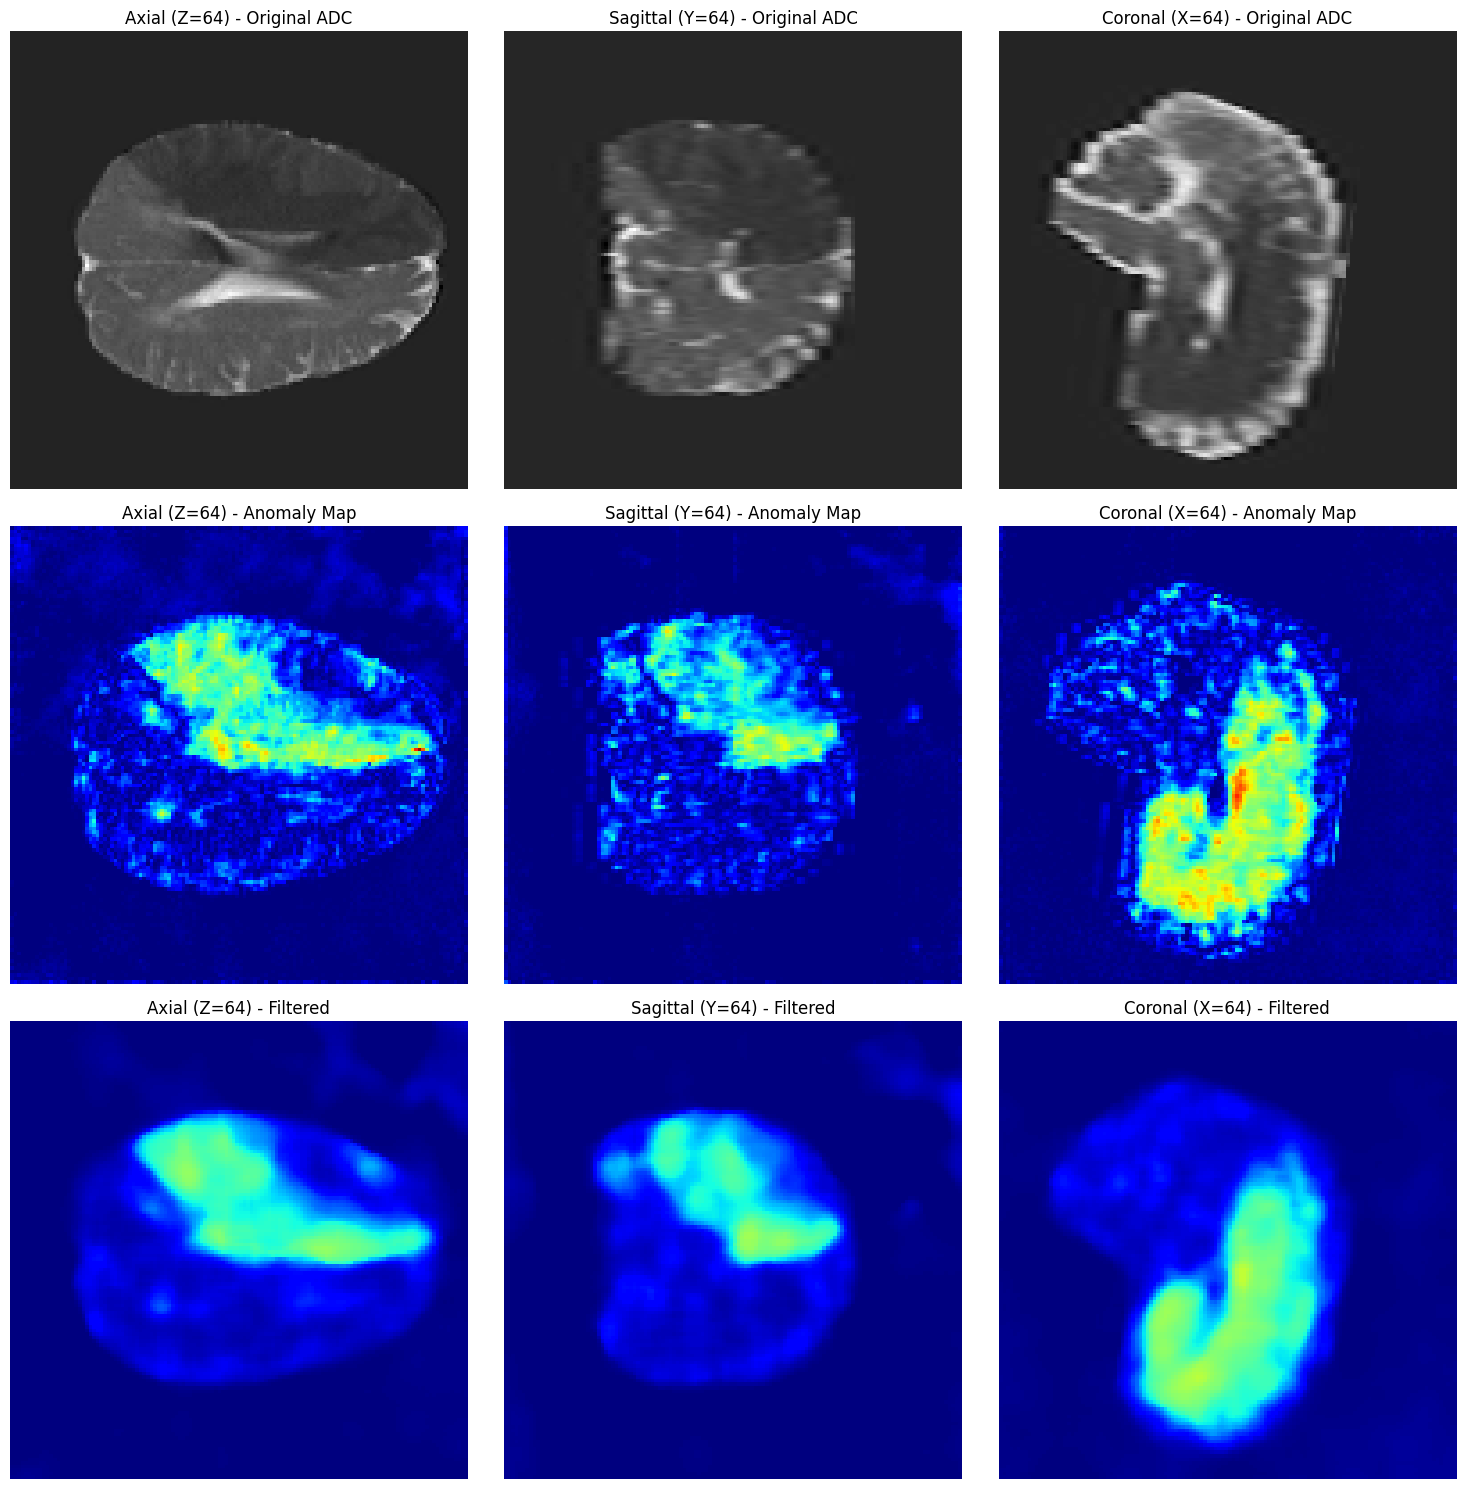

In [26]:
max_display_value = 0.3

for idx, file in enumerate(combined_ano_maps):
    if "sub-303" in file:
        
        # Load original ADC image
        adc_path = os.path.join(original_adc_folder, file.replace("ano_map_", "").replace("_t_110", ""))
        adc_img = nib.load(adc_path)
        adc_original_data = adc_img.get_fdata()

        # Load ADC anomaly map
        adc_ano_map_path = os.path.join(adc_anomaly_maps_folder, file)
        adc_ano_map_img = nib.load(adc_ano_map_path)
        adc_ano_map_data = adc_ano_map_img.get_fdata()

        # Get middle slices for visualization
        slice_z = adc_ano_map_data.shape[2] // 2  # axial
        slice_y = adc_ano_map_data.shape[1] // 2  # sagittal
        slice_x = adc_ano_map_data.shape[0] // 2  # coronal
        
        # Original ADC slices
        axial_original = adc_original_data[:, :, slice_z]
        sagittal_original = adc_original_data[:, slice_y, :]
        coronal_original = adc_original_data[slice_x, :, :]
        
        # Anomaly map slices
        axial_slice = adc_ano_map_data[:, :, slice_z]
        sagittal_slice = adc_ano_map_data[:, slice_y, :]
        coronal_slice = adc_ano_map_data[slice_x, :, :]
        
        # Apply median filter
        if adc_median_filter_size > 1:
            filtered_adc_data = median_filter(adc_ano_map_data, size=adc_median_filter_size)
        else:
            filtered_adc_data = adc_ano_map_data
        
        axial_filtered = filtered_adc_data[:, :, slice_z]
        sagittal_filtered = filtered_adc_data[:, slice_y, :]
        coronal_filtered = filtered_adc_data[slice_x, :, :]
        
        print(f"Sample {idx+1}: {file}")
        print(f"  Axial shape: {axial_slice.shape}, Sagittal shape: {sagittal_slice.shape}, Coronal shape: {coronal_slice.shape}")
        
        # Create figure with 3x3 subplots (original ADC, anomaly map, filtered)
        fig_3d, axes_3d = plt.subplots(3, 3, figsize=(15, 15))
        
        # Original ADC images (top row)
        axes_3d[0, 0].imshow(axial_original, cmap='gray')
        axes_3d[0, 0].set_title(f'Axial (Z={slice_z}) - Original ADC')
        axes_3d[0, 0].axis('off')
        
        axes_3d[0, 1].imshow(sagittal_original, cmap='gray')
        axes_3d[0, 1].set_title(f'Sagittal (Y={slice_y}) - Original ADC')
        axes_3d[0, 1].axis('off')
        
        axes_3d[0, 2].imshow(coronal_original, cmap='gray')
        axes_3d[0, 2].set_title(f'Coronal (X={slice_x}) - Original ADC')
        axes_3d[0, 2].axis('off')
        
        # Original anomaly maps (middle row)
        axes_3d[1, 0].imshow(axial_slice, cmap='jet', vmin=0, vmax=max_display_value)
        axes_3d[1, 0].set_title(f'Axial (Z={slice_z}) - Anomaly Map')
        axes_3d[1, 0].axis('off')
        
        axes_3d[1, 1].imshow(sagittal_slice, cmap='jet', vmin=0, vmax=max_display_value)
        axes_3d[1, 1].set_title(f'Sagittal (Y={slice_y}) - Anomaly Map')
        axes_3d[1, 1].axis('off')
        
        axes_3d[1, 2].imshow(coronal_slice, cmap='jet', vmin=0, vmax=max_display_value)
        axes_3d[1, 2].set_title(f'Coronal (X={slice_x}) - Anomaly Map')
        axes_3d[1, 2].axis('off')
        
        # Filtered maps (bottom row)
        axes_3d[2, 0].imshow(axial_filtered, cmap='jet', vmin=0, vmax=max_display_value)
        axes_3d[2, 0].set_title(f'Axial (Z={slice_z}) - Filtered')
        axes_3d[2, 0].axis('off')
        
        axes_3d[2, 1].imshow(sagittal_filtered, cmap='jet', vmin=0, vmax=max_display_value)
        axes_3d[2, 1].set_title(f'Sagittal (Y={slice_y}) - Filtered')
        axes_3d[2, 1].axis('off')
        
        axes_3d[2, 2].imshow(coronal_filtered, cmap='jet', vmin=0, vmax=max_display_value)
        axes_3d[2, 2].set_title(f'Coronal (X={slice_x}) - Filtered')
        axes_3d[2, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        break

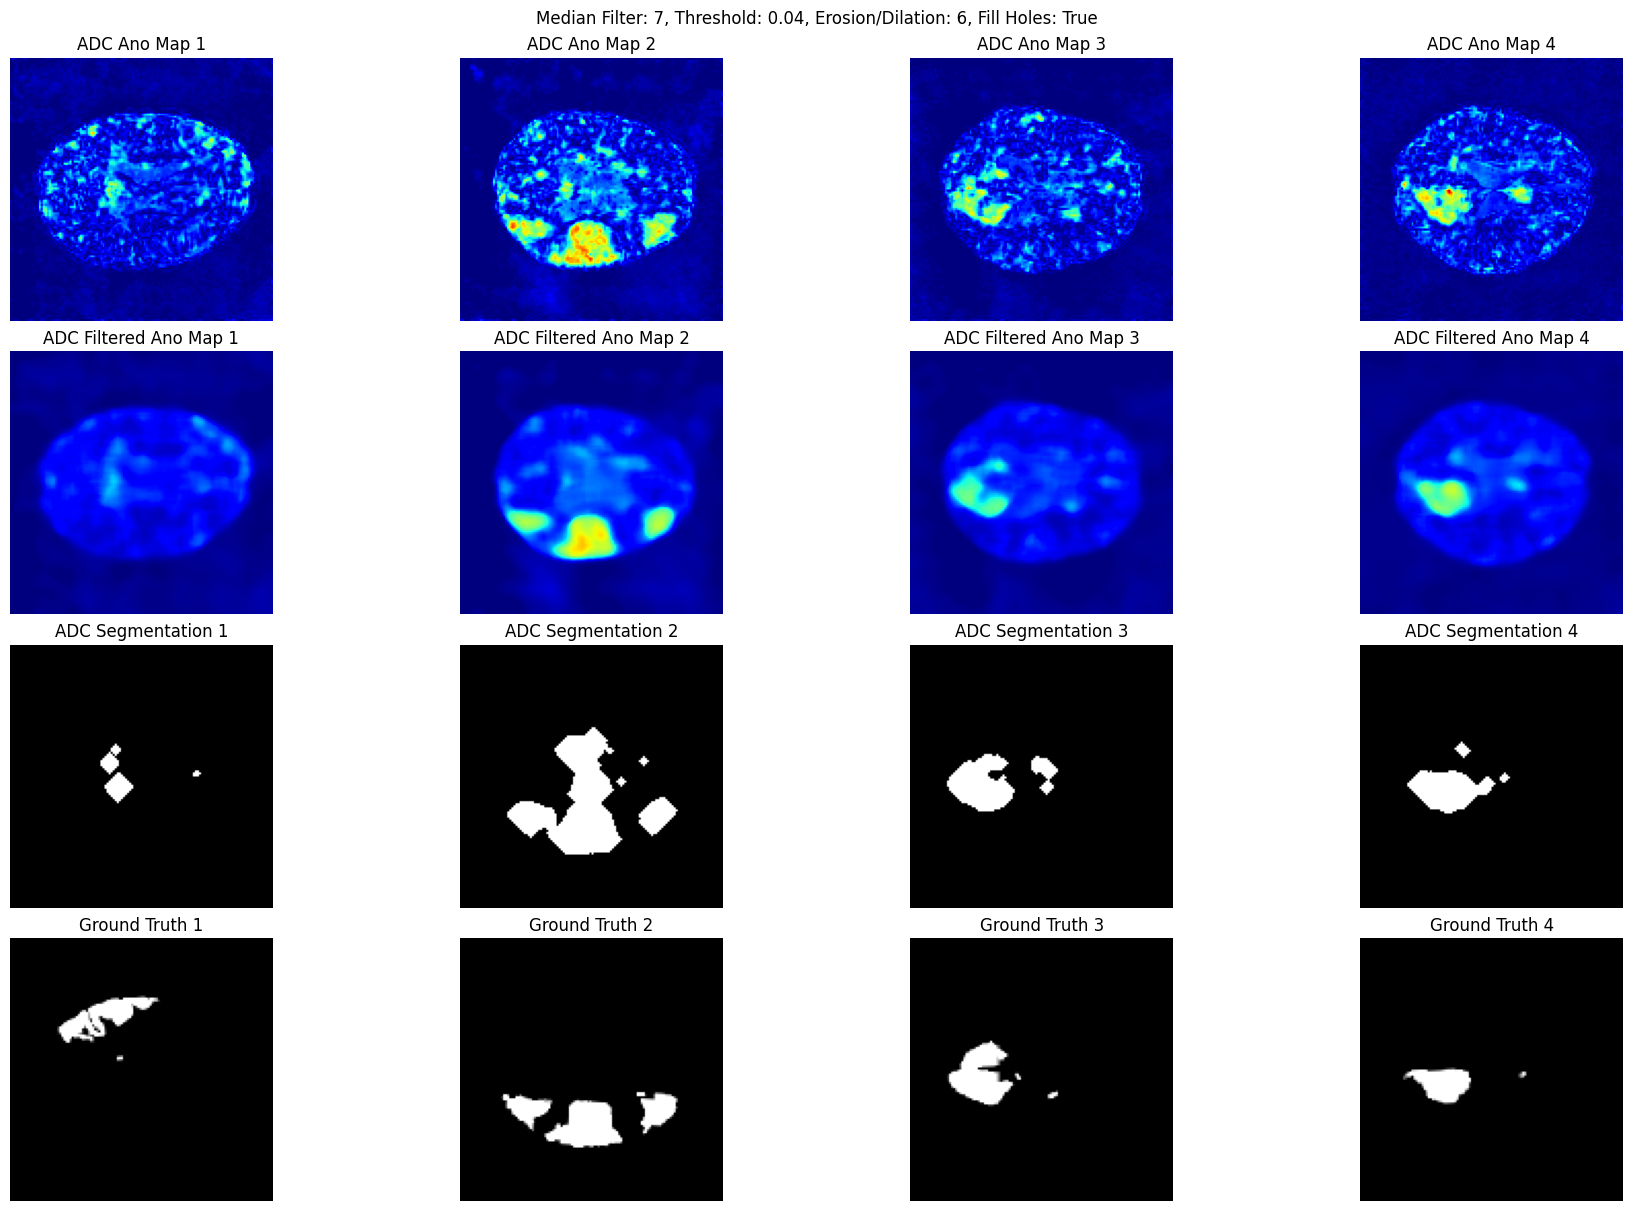

In [17]:
# ----------- PLOT -----------

fig, axes = plt.subplots(4, 4, figsize=(18, 12), constrained_layout=True)

# Load first 4 samples from combined anomaly maps
sample_files = combined_ano_maps[:4]

for idx, file in enumerate(sample_files):
    # Load ADC anomaly map
    adc_ano_map_path = os.path.join(adc_anomaly_maps_folder, file)
    adc_ano_map_img = nib.load(adc_ano_map_path)
    adc_ano_map_data = adc_ano_map_img.get_fdata()
    
    # Load ground truth mask
    mask_path = os.path.join(combined_masks_folder, file.replace("ano_map_", ""))
    mask_img = nib.load(mask_path.replace("_t_110", ""))
    mask_data = mask_img.get_fdata()
    
    # Get middle slice for visualization
    slice_idx = adc_ano_map_data.shape[-1] // 2
    adc_ano_slice = adc_ano_map_data[:, :, slice_idx]
    gt_slice = mask_data[:, :, slice_idx]
    
    # ADC anomaly map
    axes[0, idx].imshow(adc_ano_slice, cmap='jet', vmin=0, vmax=0.25)
    axes[0, idx].set_title(f'ADC Ano Map {idx+1}')
    axes[0, idx].axis('off')
    
    # Apply median filter
    if adc_median_filter_size > 1:
        filtered_map = median_filter(adc_ano_map_data, size=adc_median_filter_size)
    else:
        filtered_map = adc_ano_map_data

    # ADC filtered anomaly map
    filtered_slice = filtered_map[:, :, slice_idx]
    axes[1, idx].imshow(filtered_slice, cmap='jet', vmin=0, vmax=0.25)
    axes[1, idx].set_title(f'ADC Filtered Ano Map {idx+1}')
    axes[1, idx].axis('off')
    
    # Apply threshold
    binary_mask = filtered_map > adc_threshold
    
    # Apply erosion/dilation
    if adc_erosion_dilation_iterations > 0:
        binary_mask = binary_erosion(binary_mask, iterations=adc_erosion_dilation_iterations)
        binary_mask = binary_dilation(binary_mask, iterations=adc_erosion_dilation_iterations)
    
    # Apply binary fill holes
    if adc_binary_fill_holes:
        binary_mask = binary_fill_holes(binary_mask)
    
    binary_slice = binary_mask[:, :, slice_idx]
    axes[2, idx].imshow(binary_slice, cmap='gray', vmin=0, vmax=1)
    axes[2, idx].set_title(f'ADC Segmentation {idx+1}')
    axes[2, idx].axis('off')
    
    # Ground truth mask
    axes[3, idx].imshow(gt_slice, cmap='gray', vmin=0, vmax=1)
    axes[3, idx].set_title(f'Ground Truth {idx+1}')
    axes[3, idx].axis('off')

# Add text with parameters
param_text = f'Median Filter: {adc_median_filter_size}, Threshold: {adc_threshold:.2f}, '
param_text += f'Erosion/Dilation: {adc_erosion_dilation_iterations}, Fill Holes: {adc_binary_fill_holes}'
fig.suptitle(param_text, fontsize=12)

plt.show()


### FLAIR Alone

In [12]:
flair_median_filter_size = 7
flair_threshold = 0.06
flair_erosion_dilation_iterations = 0
flair_binary_fill_holes = True

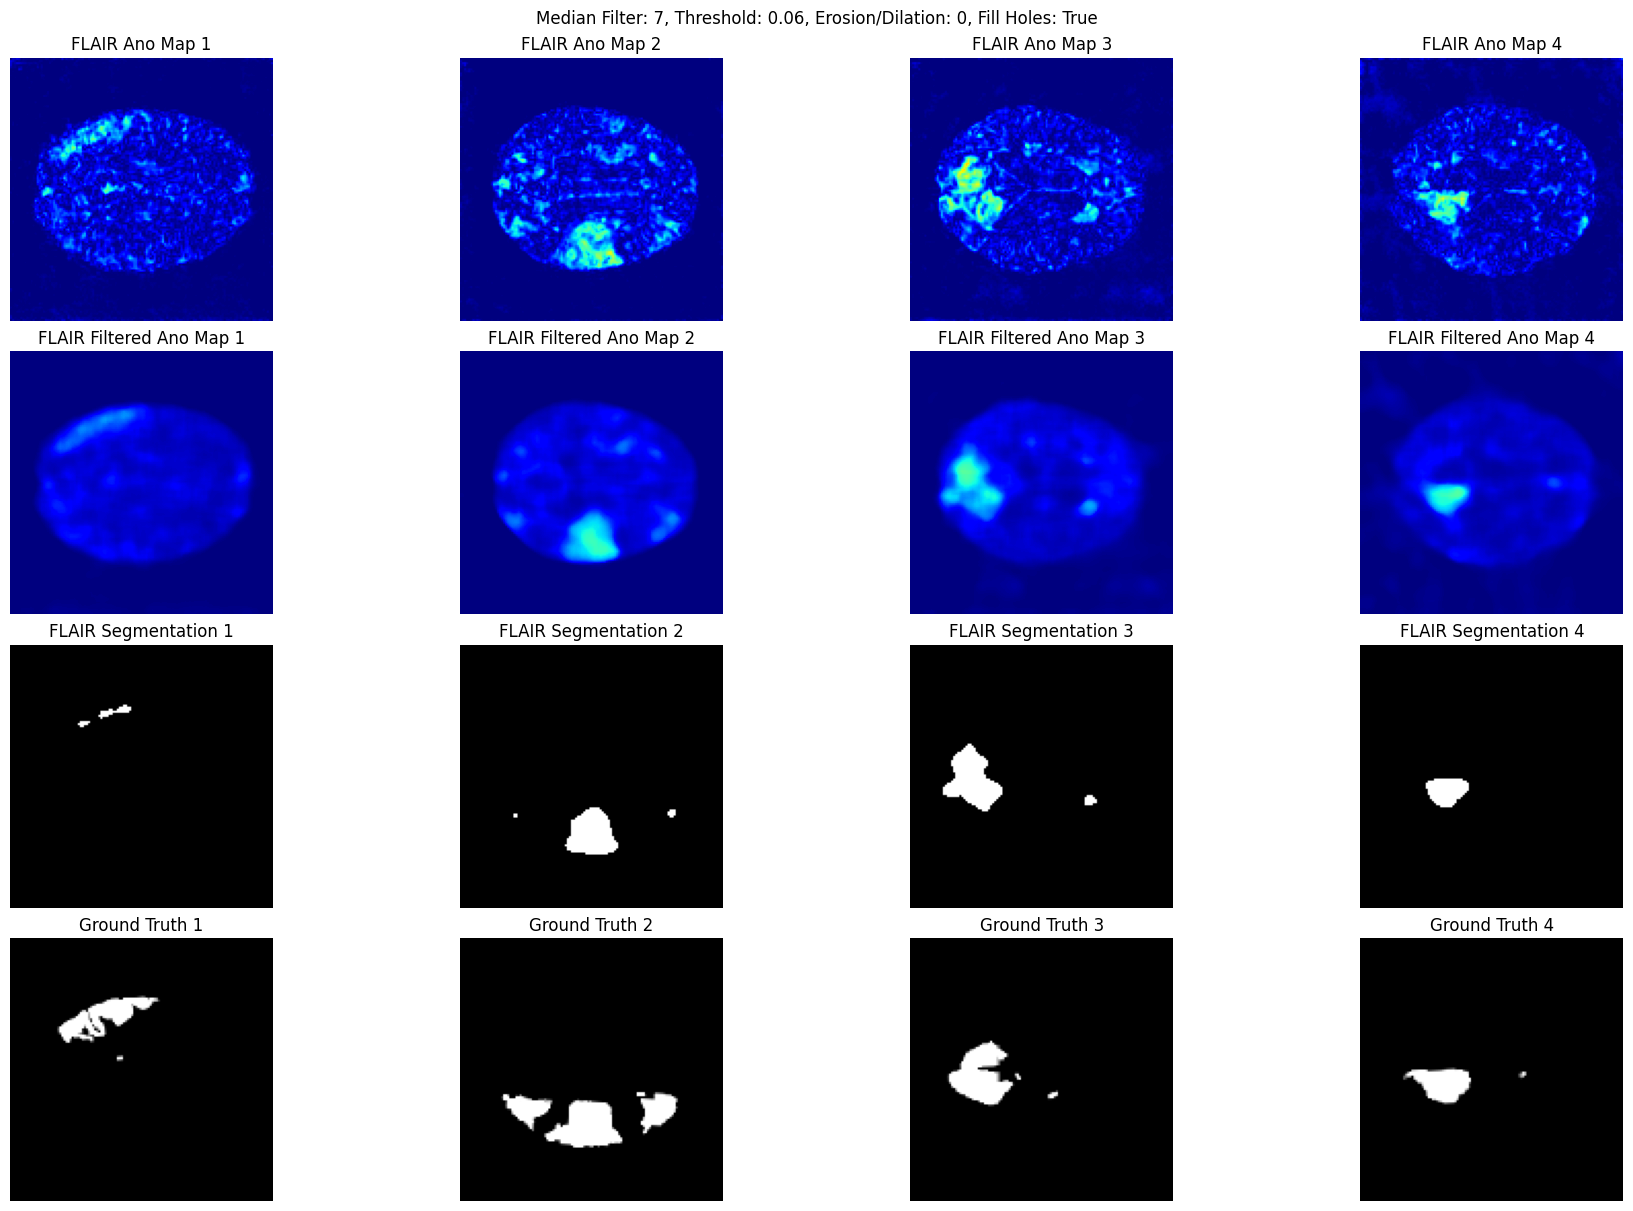

In [16]:
# ----------- PLOT -----------

fig, axes = plt.subplots(4, 4, figsize=(18, 12), constrained_layout=True)

# Load first 4 samples from combined anomaly maps
sample_files = combined_ano_maps[:4]

for idx, file in enumerate(sample_files):
    # Load ADC anomaly map
    flair_ano_map_path = os.path.join(flair_anomaly_maps_folder, file.replace(f"_t_{110}", f"_t_{90}"))
    flair_ano_map_img = nib.load(flair_ano_map_path)
    flair_ano_map_data = flair_ano_map_img.get_fdata()
    
    # Load ground truth mask
    mask_path = os.path.join(combined_masks_folder, file.replace("ano_map_", ""))
    mask_img = nib.load(mask_path.replace("_t_110", ""))
    mask_data = mask_img.get_fdata()
    
    # Get middle slice for visualization
    slice_idx = flair_ano_map_data.shape[-1] // 2
    flair_ano_slice = flair_ano_map_data[:, :, slice_idx]
    gt_slice = mask_data[:, :, slice_idx]
    
    # flair anomaly map
    axes[0, idx].imshow(flair_ano_slice, cmap='jet', vmin=0, vmax=0.25)
    axes[0, idx].set_title(f'FLAIR Ano Map {idx+1}')
    axes[0, idx].axis('off')
    
    # Apply median filter
    if flair_median_filter_size > 1:
        filtered_map = median_filter(flair_ano_map_data, size=flair_median_filter_size)
    else:
        filtered_map = flair_ano_map_data
    
    # filtered flair anomaly map
    filtered_slice = filtered_map[:, :, slice_idx]
    axes[1, idx].imshow(filtered_slice, cmap='jet', vmin=0, vmax=0.25)
    axes[1, idx].set_title(f'FLAIR Filtered Ano Map {idx+1}')
    axes[1, idx].axis('off')

    # Apply threshold
    binary_mask = filtered_map > flair_threshold
    
    # Apply erosion/dilation
    if flair_erosion_dilation_iterations > 0:
        binary_mask = binary_erosion(binary_mask, iterations=flair_erosion_dilation_iterations)
        binary_mask = binary_dilation(binary_mask, iterations=flair_erosion_dilation_iterations)
    
    # Apply binary fill holes
    if flair_binary_fill_holes:
        binary_mask = binary_fill_holes(binary_mask)
    
    binary_slice = binary_mask[:, :, slice_idx]
    axes[2, idx].imshow(binary_slice, cmap='gray', vmin=0, vmax=1)
    axes[2, idx].set_title(f'FLAIR Segmentation {idx+1}')
    axes[2, idx].axis('off')
    
    # Ground truth mask
    axes[3, idx].imshow(gt_slice, cmap='gray', vmin=0, vmax=1)
    axes[3, idx].set_title(f'Ground Truth {idx+1}')
    axes[3, idx].axis('off')

# Add text with parameters
param_text = f'Median Filter: {flair_median_filter_size}, Threshold: {flair_threshold:.2f}, '
param_text += f'Erosion/Dilation: {flair_erosion_dilation_iterations}, Fill Holes: {flair_binary_fill_holes}'
fig.suptitle(param_text, fontsize=12)

plt.show()
